In [1]:
import pickle
import pandas as pd
import copy
import numpy as np
import scipy.stats as stats
import ast
import seaborn as sns
from matplotlib import colors
import matplotlib.pyplot as plt
from _helper_functions import cb
from _helper_functions import dprint
from _helper_functions import zipdf

In [2]:
fn='supp/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'

allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq',drop=False)
allDF.head()

,enhancer-id,enhancer-sites,wt-enhancer-seq,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:0,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,OLS WT,Neural,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:1,S1-G1F-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,OLS:2,S1-G1R-S2-E1F-S3-E2F-S4-G2F-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,OLS:3,S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3R-S6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,NaN,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,OLS:4,S1-G1R-S2-E1R-S3-E2F-S4-G2R-S5-G3F-S6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,NaN,NaN,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


In [3]:
fn='supp/OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [4]:
fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [5]:
OLSName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [6]:
with open('supp/OLSName2SyntaxFamily-vary-aff.pydict.pickle','rb') as f:OLSName2SyntaxFamily=pickle.load(f)
with open('supp/SyntaxFamily2OLSName-vary-aff.pydict.pickle','rb') as f:SyntaxFamily2OLSName=pickle.load(f)    

In [7]:
dprint(SyntaxFamily2OLSName)

L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6 {'L1-G3R-L2-E1F-L3-E2F-L4-G2R-L5-G1F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G3R-L5-G1F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6', 'L1-G1R-L2-E1F-L3-E2F-L4-G3R-L5-G2F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G2R-L5-G1F-L6', 'L1-G3R-L2-E1F-L3-E2F-L4-G1R-L5-G2F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G3R-L5-G2F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G3R-L5-G1F-L6', 'L1-G3R-L2-E2F-L3-E1F-L4-G1R-L5-G2F-L6', 'L1-G2R-L2-E1F-L3-E2F-L4-G1R-L5-G3F-L6', 'L1-G1R-L2-E2F-L3-E1F-L4-G2R-L5-G3F-L6', 'L1-G2R-L2-E2F-L3-E1F-L4-G1R-L5-G3F-L6'}


In [8]:
dprint(OLSName2SyntaxFamily)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6


# Generate (or load) Syntax Family Data

In [9]:
activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

synFamilies=[]
allFuncEns=[]
allNonFuncEns=[]
enFuncCounts=[]
enNonfuncCounts=[]
SyntaxFamily2Info={} # number functional and nonfunctional

for synFam,synVariants in SyntaxFamily2OLSName.items():

    synFamActivities=[]
    for tfbsList in synVariants:
        
        en=OLSName2Seq[tfbsList]
        
        if en in idxSet:  activity=allDF.at[en,activityColumn]
        else:             activity=0
            
        synFamActivities.append(activity)
        
        
    nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
    funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])
    
    if funcCounts==12:      
        allFuncEns.append(synFam)
        
    if nonFuncCounts==12:   
        allNonFuncEns.append(synFam)
    
    enFuncCounts.append(funcCounts)
    enNonfuncCounts.append(nonFuncCounts)
    synFamilies.append(synFam)
    
    SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)
    

c2v={'syntax-family':synFamilies,'n-func':enFuncCounts,'n-inert':enNonfuncCounts,'n-func-inert-tuple':[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]}
famDF=pd.DataFrame(c2v)
famDF.head()

#famDF.to_csv('F03-Syntax-Families/syntax-fam-table-real-data.tsv',index=None,sep='\t')

,syntax-family,n-func,n-inert,n-func-inert-tuple
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,4,2,"(4, 2)"
1,L1-GF-L2-EF-L3-EF-L4-GR-L5-GF-L6,2,4,"(2, 4)"
2,L1-GR-L2-EF-L3-EF-L4-GF-L5-GF-L6,1,4,"(1, 4)"
3,L1-GR-L2-EF-L3-EF-L4-GR-L5-GR-L6,3,1,"(3, 1)"
4,L1-GR-L2-ER-L3-EF-L4-GR-L5-GF-L6,4,1,"(4, 1)"


In [ ]:
# if you already have the file
#famDF=pd.read_csv('F03-Syntax-Families//syntax-fam-table-real-data.tsv',sep='\t')

In [10]:
Bin2RealCount={}

for nfunc,ninert in zipdf(famDF,['n-func','n-inert']):
    if (nfunc,ninert) not in Bin2RealCount:
        Bin2RealCount[nfunc,ninert]=0
    Bin2RealCount[nfunc,ninert]+=1
        

# Generate (or load) Permuted Syntax Family Data

In [11]:
npermutations=100

In [12]:
activityColumn='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0
idxSet=set(allDF.index)

for permuteIter in range(npermutations):
    
    print(permuteIter,end=',  ')
    
    permEnhancers=np.random.permutation(allDF['wt-enhancer-seq'])
    allDF['wt-enhancer-seq']=permEnhancers
    allDF=allDF.set_index('wt-enhancer-seq',drop=False)

    
    synFamilies=[]
    allFuncEns=[]
    allNonFuncEns=[]
    enFuncCounts=[]
    enNonfuncCounts=[]
    SyntaxFamily2Info={} # number functional and nonfunctional
    for synFam,synVariants in SyntaxFamily2OLSName.items():


        synFamActivities=[]
        for tfbsList in synVariants:
            en=OLSName2Seq[tfbsList]

            if en in idxSet:  activity=allDF.at[en,activityColumn]
            else:             activity=0

            synFamActivities.append(activity)


        nonFuncCounts=sum([i<=thresholdToLabelNegatives for i in synFamActivities])
        funcCounts   =sum([i>=thresholdToLabelPositives for i in synFamActivities])

        if funcCounts==12:      
            allFuncEns.append(synFam)

        if nonFuncCounts==12:   
            allNonFuncEns.append(synFam)

        enFuncCounts.append(funcCounts)
        enNonfuncCounts.append(nonFuncCounts)
        synFamilies.append(synFam)

        SyntaxFamily2Info[synFam]=(funcCounts,nonFuncCounts)

    famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]

#famDF.to_pickle(f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.pd.df.pickle')
#famDF.to_csv(   f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.tsv',sep='\t',index=None)

0,  1,  2,  3,  4,  5,  6,  7,  8,  9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_88300/1065188742.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]


99,  

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_88300/1065188742.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  famDF[f'n-func-inert-tuple-permute-{permuteIter}']=[(i,j) for i,j in zip(enFuncCounts,enNonfuncCounts)]


In [16]:
famDF=pd.read_pickle(f'F03-Syntax-Families/syntax-family-analysis-table-with-permuted-data_numiters={npermutations}.pd.df.pickle')

In [13]:
famDF.head(1)

,syntax-family,n-func,n-inert,n-func-inert-tuple,n-func-inert-tuple-permute-0,n-func-inert-tuple-permute-1,n-func-inert-tuple-permute-2,n-func-inert-tuple-permute-3,n-func-inert-tuple-permute-4,n-func-inert-tuple-permute-5,...,n-func-inert-tuple-permute-90,n-func-inert-tuple-permute-91,n-func-inert-tuple-permute-92,n-func-inert-tuple-permute-93,n-func-inert-tuple-permute-94,n-func-inert-tuple-permute-95,n-func-inert-tuple-permute-96,n-func-inert-tuple-permute-97,n-func-inert-tuple-permute-98,n-func-inert-tuple-permute-99
0,L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6,4,2,"(4, 2)","(2, 3)","(2, 3)","(1, 5)","(1, 5)","(5, 4)","(0, 3)",...,"(1, 4)","(2, 4)","(3, 3)","(3, 3)","(1, 4)","(4, 4)","(5, 2)","(0, 7)","(1, 3)","(4, 3)"


In [18]:
# z-normalize counts 

# get raw ccounts
Bin2NullCountList={}

for col in [ci for ci in famDF.columns if 'n-func-inert-tuple-permute' in ci]:
    
    bin2count={bi : famDF[col].tolist().count(bi) for bi in famDF[col].unique()}
    
    for bi,count in bin2count.items():
        if bi not in Bin2NullCountList:
            Bin2NullCountList[bi]=[]
        Bin2NullCountList[bi].append(count)


In [19]:
allBins=set()
for i in range(0,13):
    for j in range(0,13):
        if i+j<=12:
            allBins.add((i,j))
            allBins.add((j,i))

In [20]:
realBinsDetected=set(famDF['n-func-inert-tuple'].unique())
permutedBinsDetected=set(Bin2NullCountList.keys())

undetectedBins=allBins-realBinsDetected-permutedBinsDetected

In [23]:
def parse_tuple(x):
    if isinstance(x, str):
        return ast.literal_eval(x)
    return x

In [24]:
# get z normalizing info

Bin2Info={bi:{'std':np.std(Bin2NullCountList[bi]), 'mean':np.mean(Bin2NullCountList[bi]), 'median':np.median(Bin2NullCountList[bi])} for bi in Bin2NullCountList}

dprint(Bin2Info,5)

print()

#  z  normalize real data

Bin2RealZ = {}

bin2realcount = {
    parse_tuple(bi): famDF["n-func-inert-tuple"].apply(parse_tuple).tolist().count(parse_tuple(bi))
    for bi in famDF["n-func-inert-tuple"].unique()
}

for bi in famDF["n-func-inert-tuple"].unique():
    bi = parse_tuple(bi)

    if bi not in Bin2Info:
        Bin2RealZ[bi] = np.inf
    else:
        std = Bin2Info[bi]["std"]

        if std == 0:
            Bin2RealZ[bi] = np.inf
        else:
            Bin2RealZ[bi] = (bin2realcount[bi] - Bin2Info[bi]["mean"]) / std

(2, 3) {'std': 53.10713323085704, 'mean': 2646.18, 'median': 2643.5}
(2, 5) {'std': 41.49725171622814, 'mean': 2064.41, 'median': 2067.0}
(4, 5) {'std': 19.57634031171301, 'mean': 401.13, 'median': 400.5}
(0, 4) {'std': 29.024327726925907, 'mean': 856.78, 'median': 858.0}
(0, 3) {'std': 26.051518189925133, 'mean': 619.28, 'median': 619.0}
(1, 4) {'std': 46.881552875304806, 'mean': 2348.0, 'median': 2349.5}



In [25]:
# if bins were not observed, this is the most extreme result. Thereore we replace these with the most sig Z score.
maxz=max([i for i in Bin2RealZ.values() if  i!=np.inf])
for bi,zi in Bin2RealZ.items():
    if zi==np.inf:
        Bin2RealZ[bi]=maxz

In [26]:
minz=min(Bin2RealZ.values())

In [27]:
# convert z score to p value
Bin2RealP={(yi,xi):stats.norm.sf(abs(zi))*2 for (yi,xi),zi in Bin2RealZ.items()}
minp=min([i for i in Bin2RealP.values() if i>0])
Bin2RealP={(yi,xi):pi if pi>0 else minp for (yi,xi),pi in Bin2RealP.items()}

In [28]:
# adjust p values
Bin2RealPAdj={(yi,xi):pi*len(Bin2RealP) for (yi,xi),pi in Bin2RealP.items()}

In [29]:

ninertlist=[]
nfunclist=[]

for bi in Bin2Info:
    numOccurences=int(Bin2Info[bi]['mean'])
    nfunc=bi[0]
    ninert=bi[1]
    
    for i in range(numOccurences):
        nfunclist.append(nfunc)
        ninertlist.append(ninert)
        

/scratch/solvason/job_5990576/ipykernel_3223827/3375189141.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#
/scratch/solvason/job_5990576/ipykernel_3223827/3375189141.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))


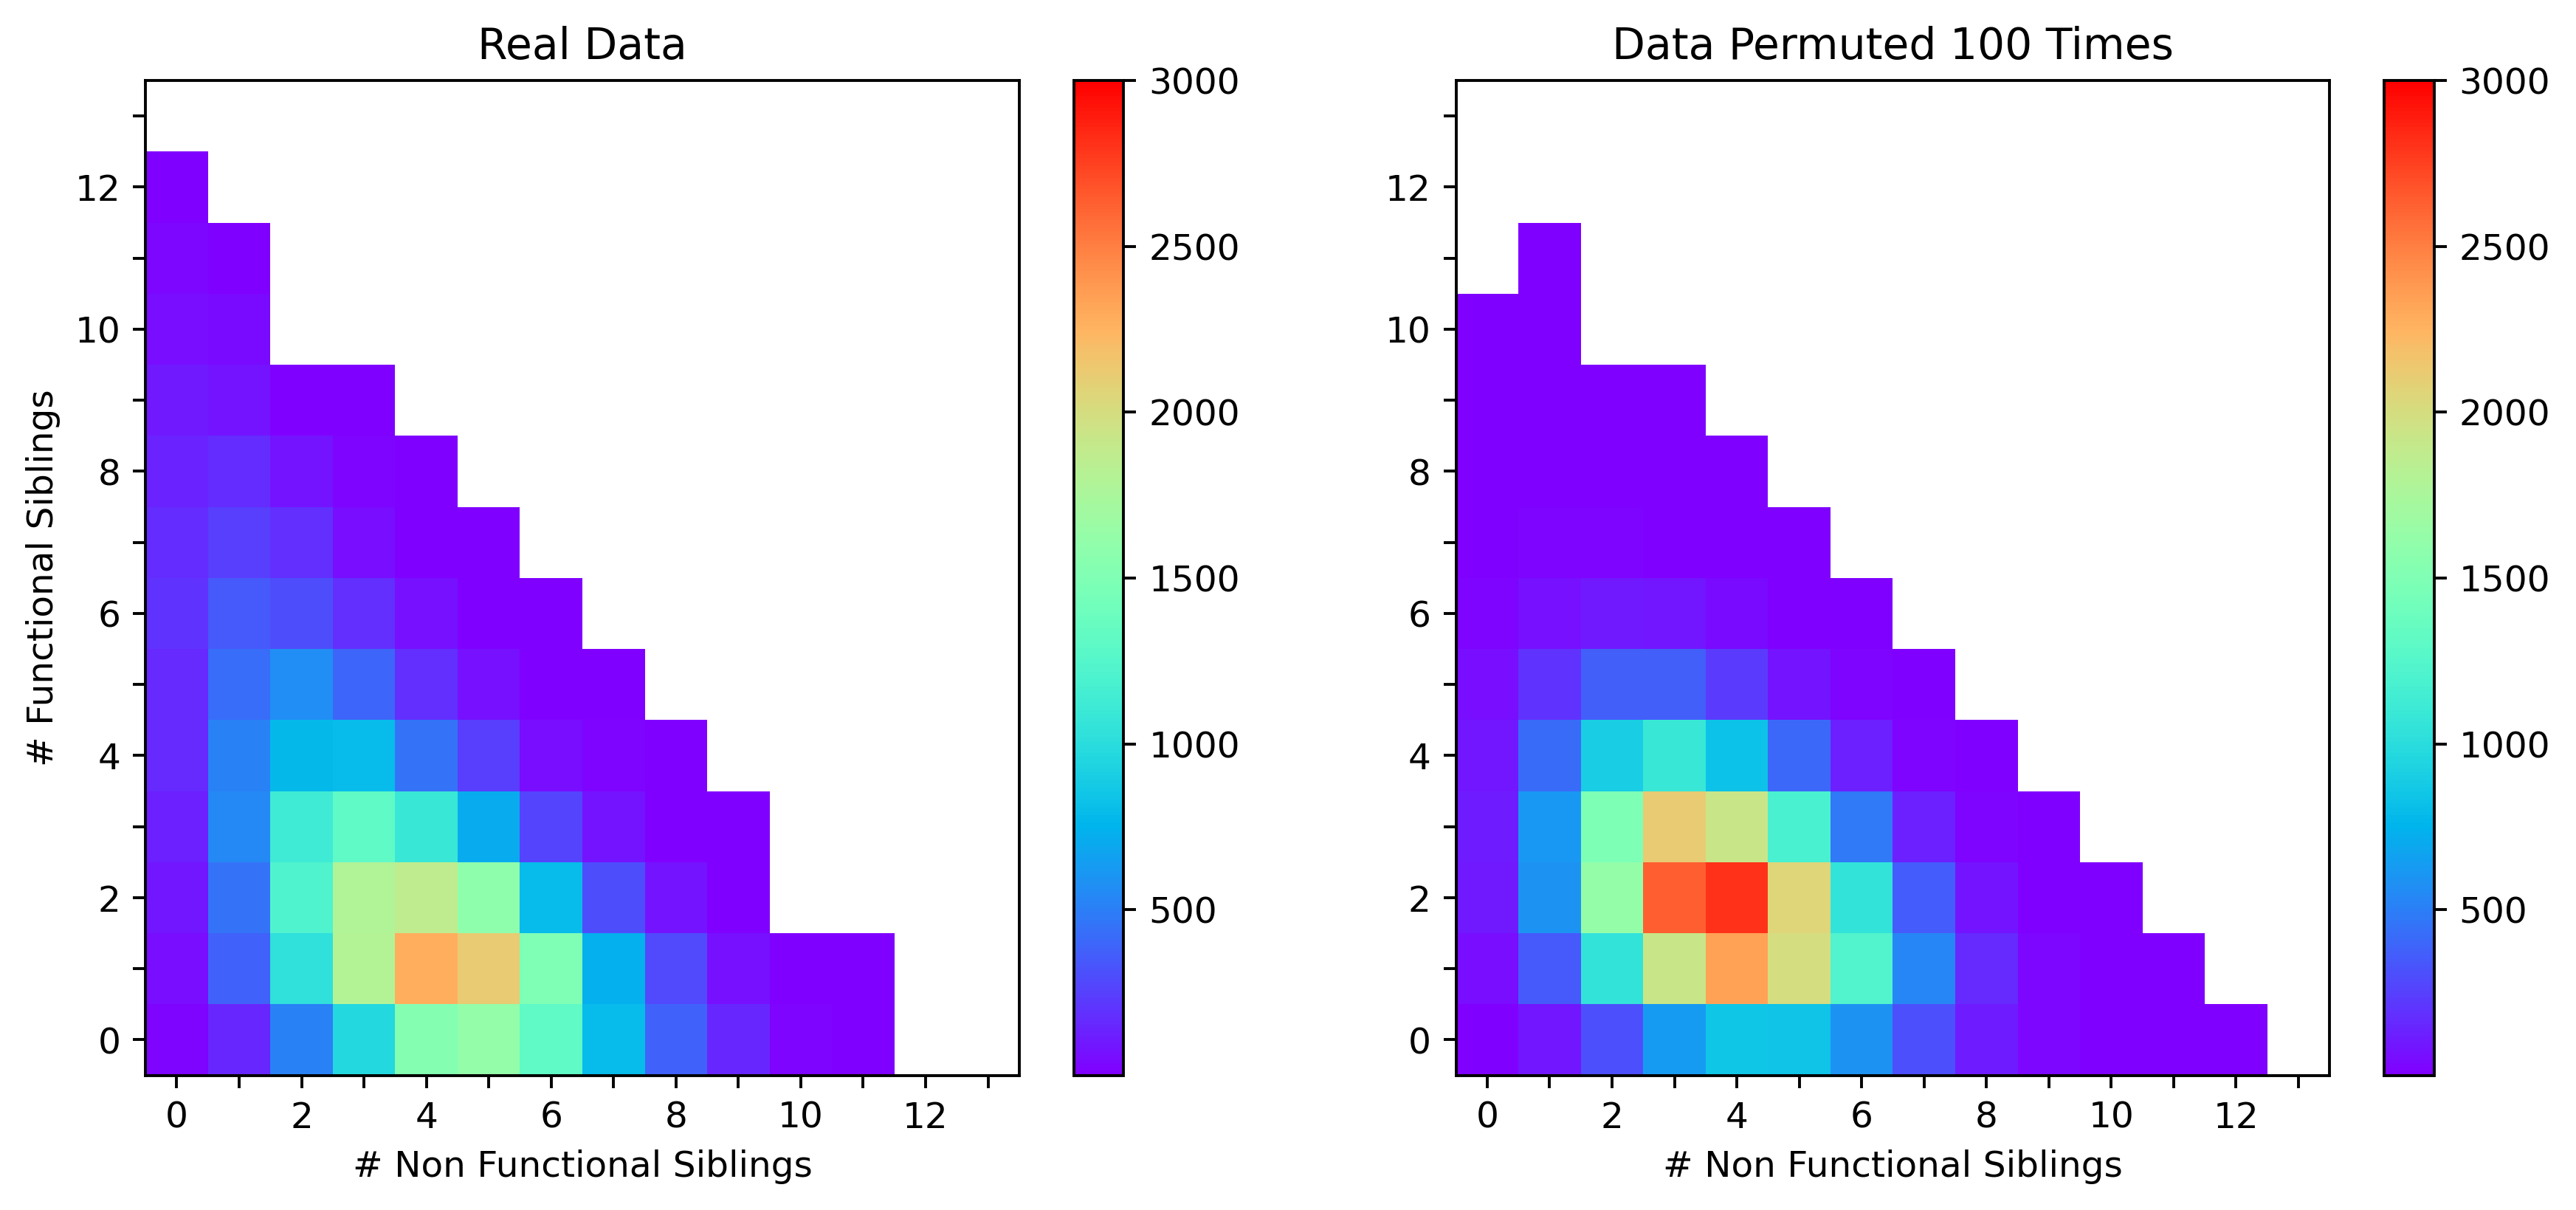

In [27]:
 
vmin=1
vmax=3000
cmin=vmin
cmax=vmax

fig,ax=plt.subplots(1, 2, figsize=(12, 5),dpi=350)

heatmap1, xedges1, yedges1, im1 = ax[0].hist2d(x=famDF['n-inert'],y=famDF['n-func'],bins=range(15),cmap=plt.cm.get_cmap('rainbow'),cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax)#

fig.colorbar(im1, ax=ax[0], orientation='vertical')        


ax[0].set_ylabel('# Functional Siblings')
ax[0].set_xlabel('# Non Functional Siblings')
ax[0].set_title('Real Data')

heatmap2, xedges2, yedges2, im2 = ax[1].hist2d(x=ninertlist,y=nfunclist,bins=(xedges1, yedges1), cmin=cmin,cmax=cmax,vmin=vmin,vmax=vmax,cmap=plt.cm.get_cmap('rainbow'))

ax[1].set_xlabel('# Non Functional Siblings')
ax[1].set_title(f'Data Permuted {npermutations} Times')


fig.colorbar(im1, ax=ax[1], orientation='vertical')        

for i in [0,1]:
    ticks=range(14)
    ax[i].set_yticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])
    ax[i].set_xticks([t+.5 for t in ticks],labels=[t if t%2==0 else '' for t in ticks])

In [14]:
with open('supp/syntax-fam-Bin2Annotation.pydict.pickle','rb') as f: 
    Bin2Annotation=pickle.load(f)

In [31]:
Annotation2Bins={anno:set() for anno in set(Bin2Annotation.values())}

for b,a in Bin2Annotation.items():
    
    Annotation2Bins[a].add(b)
    

In [16]:
anno2color={
    "":"white",
    "Inert":cb['orangenature'],
    "Moderate":'darkgrey',
    "Robust":cb['green'],
}


 	 3,776
Moderate 	 32,785
Robust 	 490
Inert 	 1,349


(-1.0, 13.0)

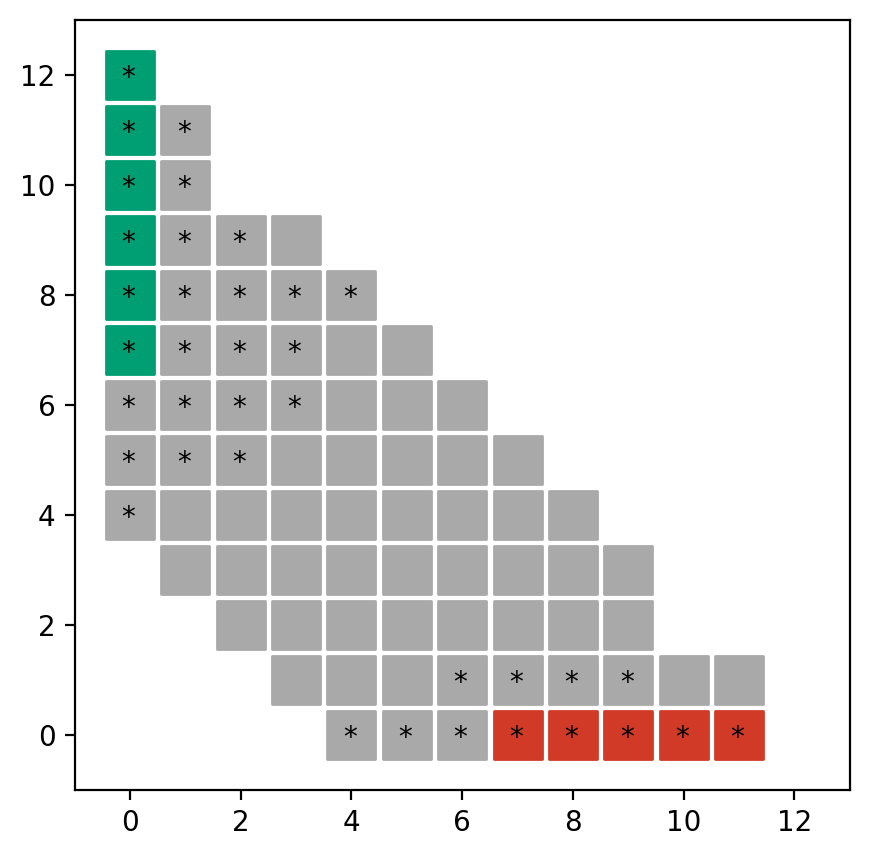

In [31]:
fig,ax=plt.subplots(1,figsize=(5,5),dpi=200)

for y,x in Bin2Annotation:
    anno=Bin2Annotation[y,x]
    color=anno2color[anno]
    
    ax.scatter(x,y,marker='s',color=color,s=300)
    
    if ((y,x) not in Bin2RealPAdj) or (anno==''): 
        p=1
        c=''

    else:                         
        p=Bin2RealPAdj[y,x]
        c=Bin2RealCount[y,x]
        if c>=1000:
            c=round(c/1000)
            c=f'{c}k'
    
    if p<1e-5 and Bin2RealZ[y,x]>0: ax.text(x-.03,y-.06,'*',ha='center',va='center')
    
for anno,bins in Annotation2Bins.items():
    
    count=0
    for b in bins:
        if b not in Bin2RealCount: continue
        count+=Bin2RealCount[b]
        
    print(anno,'\t',f'{count:,}')
    
    
ax.set_ylim(-1,13)
ax.set_xlim(-1,13)

# ax.set_yticklabels([])
# ax.set_xticklabels([])


# js.clearspines(ax)
